In [2]:
import pandas as pd
import plotly.express as px

In [3]:
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")
sip.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,NaN
1,2022-02,11438,4.93,8.20,4.85,NaN
2,2022-03,12328,5.09,10.50,5.01,NaN
3,2022-04,11863,5.48,9.52,5.12,NaN
4,2022-05,12286,5.55,8.10,5.15,NaN


In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.style.use("ggplot")

In [5]:
fund_master = pd.read_csv("../data/raw/01_fund_master.csv")
nav = pd.read_csv("../data/raw/02_nav_history.csv")
aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")
category = pd.read_csv("../data/raw/05_category_inflows.csv")
folios = pd.read_csv("../data/raw/06_industry_folio_count.csv")
performance = pd.read_csv("../data/raw/07_scheme_performance.csv")
investors = pd.read_csv("../data/raw/08_investor_transactions.csv")
holdings = pd.read_csv("../data/raw/09_portfolio_holdings.csv")
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [6]:
fund_master.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [7]:
nav["date"] = pd.to_datetime(nav["date"])

fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="NAV Trend Analysis (2022-2026)"
)

fig.show()

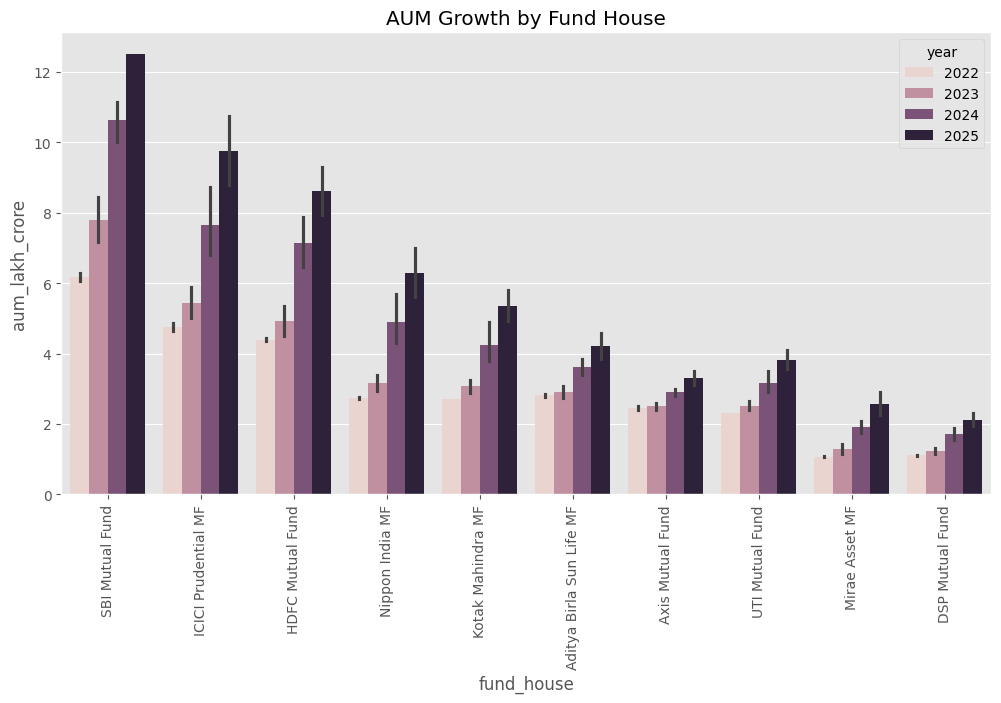

<Figure size 640x480 with 0 Axes>

In [8]:
aum["year"] = pd.to_datetime(aum["date"]).dt.year

plt.figure(figsize=(12,6))

sns.barplot(
    data=aum,
    x="fund_house",
    y="aum_lakh_crore",
    hue="year"
)

plt.xticks(rotation=90)
plt.title("AUM Growth by Fund House")
plt.show()
plt.savefig("../reports/aum_growth.png", bbox_inches="tight")

In [9]:
sip["month"] = pd.to_datetime(sip["month"])

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflows (2022-2025)"
)

fig.show()

In [10]:
fig.write_image("../reports/sip_trend.png")

## Insight 1
Mutual fund NAVs showed a generally upward trend from 2022 to 2026, indicating long-term growth potential.

## Insight 2
SBI Mutual Fund maintained one of the highest AUM levels among major fund houses.

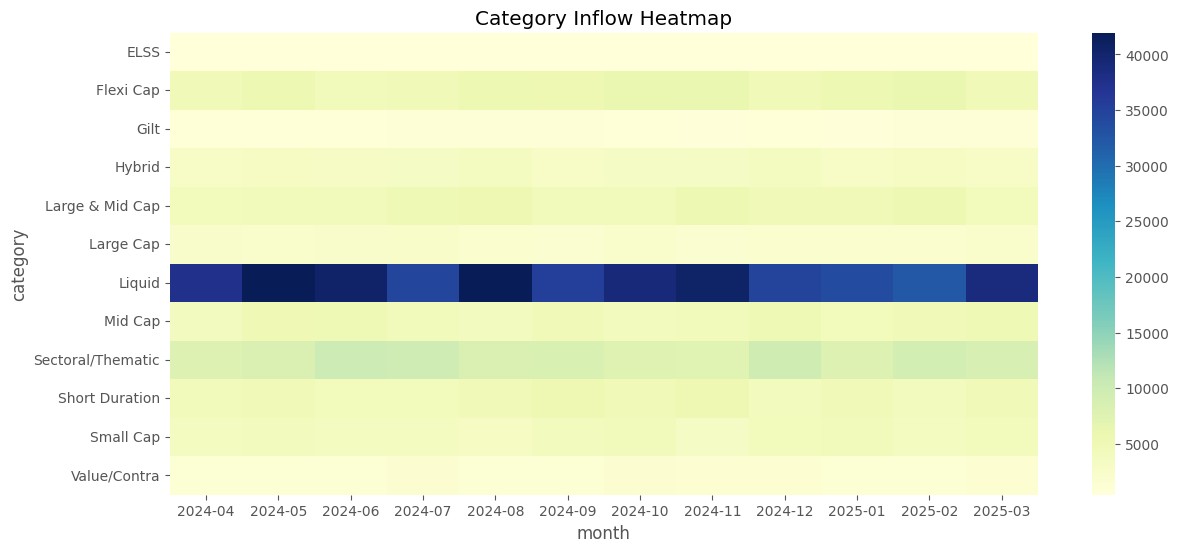

In [11]:
category_pivot = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(14,6))
sns.heatmap(category_pivot, cmap="YlGnBu")

plt.title("Category Inflow Heatmap")
plt.show()

## Insight 3
Large Cap, Mid Cap, and Flexi Cap categories consistently attracted higher inflows than most other categories.

## Insight 4
Some categories experienced significant month-to-month variations in net inflows, indicating changing investor preferences.

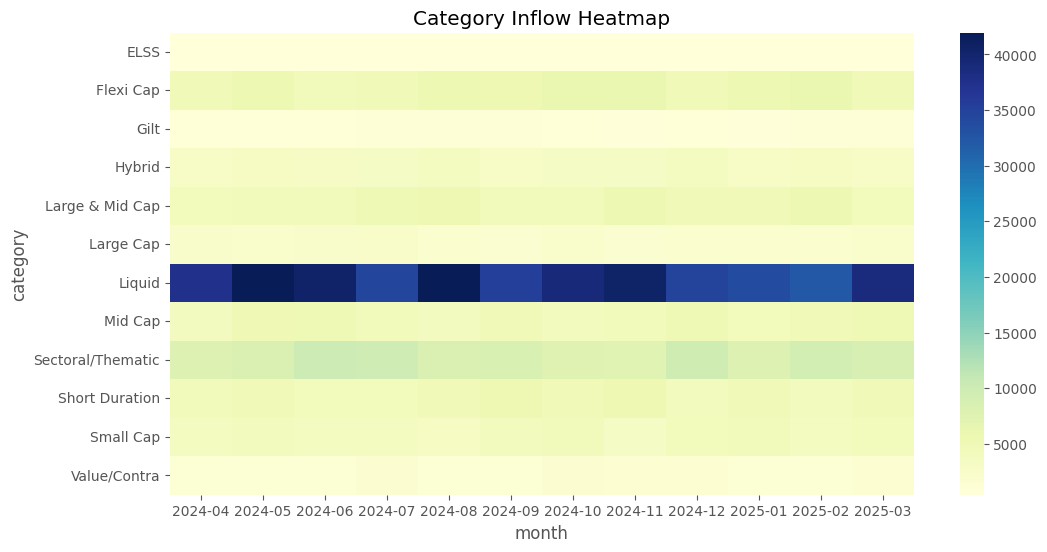

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

heatmap_data = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(12,6))
sns.heatmap(heatmap_data, cmap="YlGnBu")
plt.title("Category Inflow Heatmap")
plt.show()

## Insight 5
Large Cap, Mid Cap, and Flexi Cap categories consistently attracted higher inflows compared to other categories.

In [16]:
print(globals().keys())

dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', 'open', '_', '__', '___', '__vsc_ipynb_file__', '__DW_SCOPE__', '_i', '_ii', '_iii', '_i1', 'pd', 'px', '_i2', '_2', '_i3', 'sip', '_3', '_i4', 'np', 'plt', 'sns', '_4', '_i5', 'fund_master', 'nav', 'aum', 'category', 'folios', 'performance', 'investors', 'holdings', 'benchmark', '_5', '_i6', '_6', '_i7', 'fig', '_i8', '_i9', '_i10', '_i11', 'category_pivot', '_11', '_i12', '_i13', '_i14', 'heatmap_data', '_i15', '_i16'])


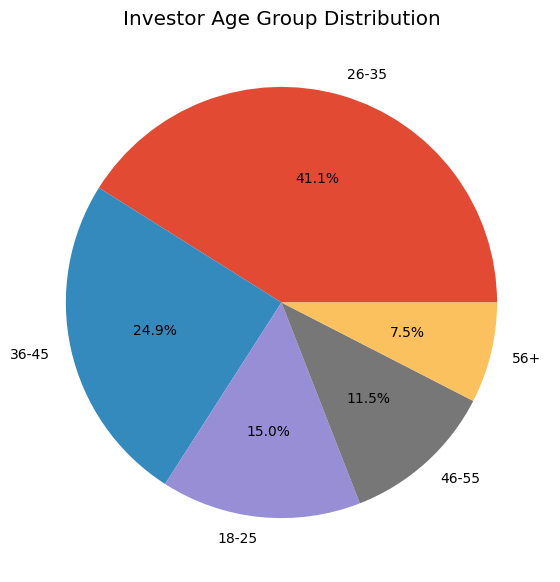

In [17]:
age_counts = investors["age_group"].value_counts()

plt.figure(figsize=(7,7))
plt.pie(age_counts, labels=age_counts.index, autopct="%1.1f%%")
plt.title("Investor Age Group Distribution")
plt.show()

## Insight 6
The majority of investors belong to middle-age categories, indicating strong participation from working professionals.

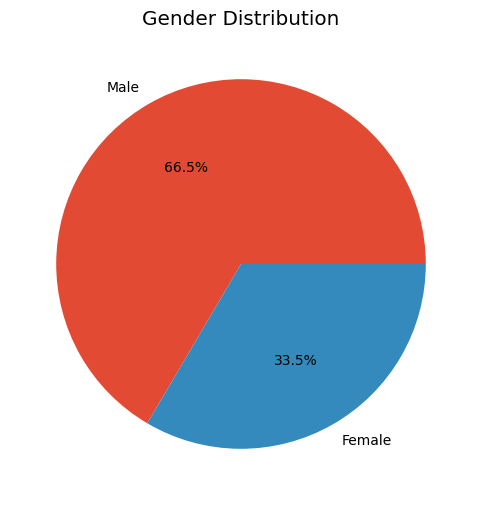

In [18]:
gender_counts = investors["gender"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(gender_counts, labels=gender_counts.index, autopct="%1.1f%%")
plt.title("Gender Distribution")
plt.show()

## Insight 7
Male investors constitute a larger share of transactions compared to female investors.

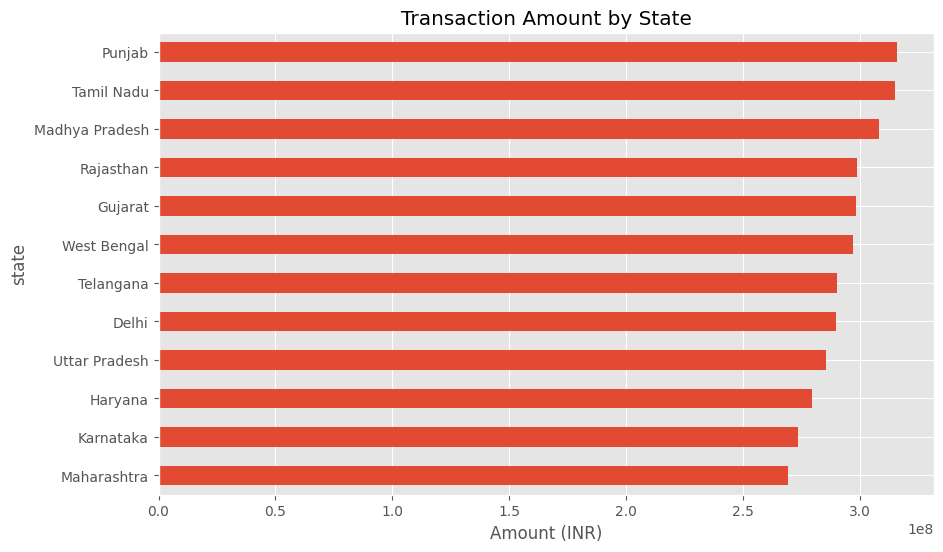

In [19]:
state_amount = investors.groupby("state")["amount_inr"].sum().sort_values()

plt.figure(figsize=(10,6))
state_amount.plot(kind="barh")
plt.title("Transaction Amount by State")
plt.xlabel("Amount (INR)")
plt.show()

## Insight 8
A few states contribute a significant share of total mutual fund investment amounts, showing geographical concentration.

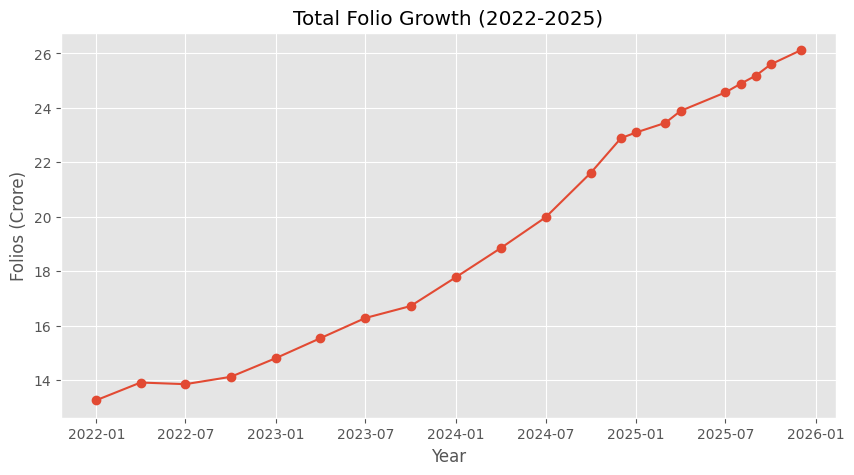

In [20]:
folios["month"] = pd.to_datetime(folios["month"])

plt.figure(figsize=(10,5))
plt.plot(folios["month"], folios["total_folios_crore"], marker="o")
plt.title("Total Folio Growth (2022-2025)")
plt.xlabel("Year")
plt.ylabel("Folios (Crore)")
plt.grid(True)
plt.show()

## Insight 9
Total mutual fund folios increased significantly between 2022 and 2025, indicating rapid growth in retail participation.

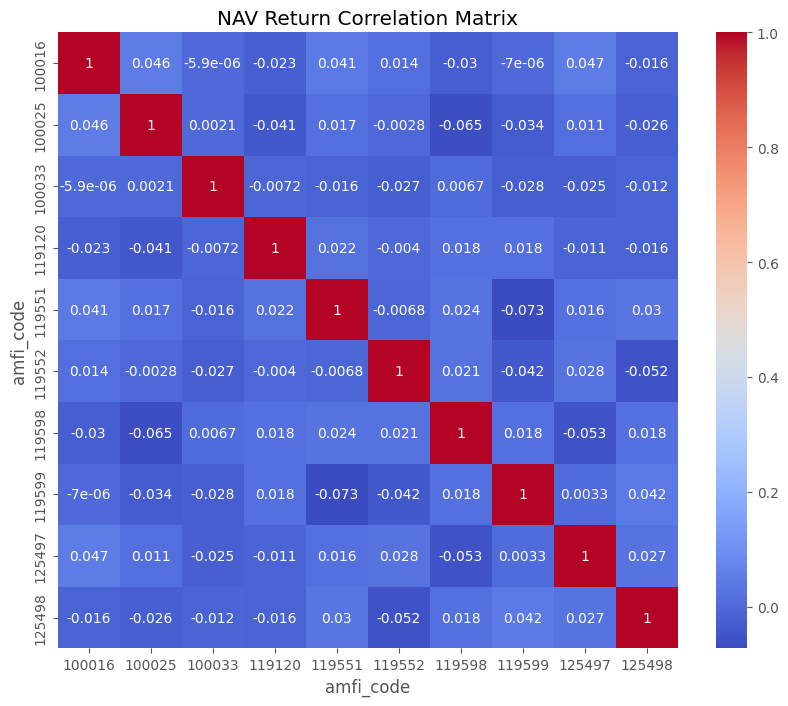

In [21]:
nav["date"] = pd.to_datetime(nav["date"])

selected_funds = nav["amfi_code"].unique()[:10]

corr_data = nav[nav["amfi_code"].isin(selected_funds)]

pivot_nav = corr_data.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

returns = pivot_nav.pct_change()

corr_matrix = returns.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("NAV Return Correlation Matrix")
plt.show()

## Insight 10
Most equity-oriented funds show positive correlation, indicating that they move broadly with overall market trends.

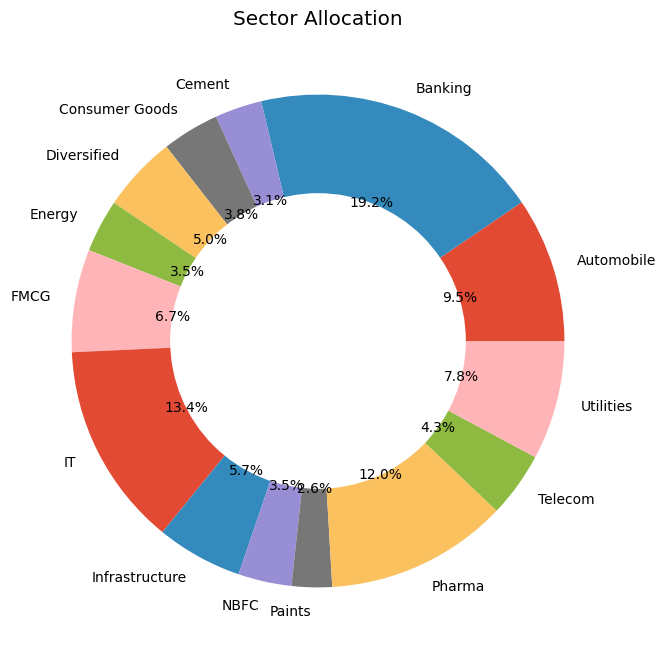

In [22]:
sector_weights = holdings.groupby("sector")["weight_pct"].sum()

plt.figure(figsize=(8,8))
plt.pie(
    sector_weights,
    labels=sector_weights.index,
    autopct="%1.1f%%"
)

centre_circle = plt.Circle((0,0),0.60,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Sector Allocation")
plt.show()